In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

# Load everything we need
model = joblib.load('../models/xgb_model.pkl')
feature_cols = joblib.load('../models/feature_cols.pkl')
scaler = joblib.load('../models/scaler.pkl')

train = pd.read_csv('../data/processed/train_features.csv')
test = pd.read_csv('../data/processed/test_features.csv')

print("SHAP version:", shap.__version__)
print("Model and data loaded.")

SHAP version: 0.51.0
Model and data loaded.


In [2]:
X_train = train[feature_cols]
X_test = test[feature_cols]

# TreeExplainer is specifically designed for XGBoost
# It's exact (not approximate) and very fast
explainer = shap.TreeExplainer(model)

print("Explainer created.")
print(f"Number of features: {len(feature_cols)}")

Explainer created.
Number of features: 98


In [3]:
# Get last cycle of each test engine - the prediction point
test_last = test.groupby('engine_id').last().reset_index()
X_test_last = test_last[feature_cols]

# Compute SHAP values
# This returns a matrix: one row per engine, one column per feature
shap_values = explainer.shap_values(X_test_last)

print(f"SHAP values shape: {shap_values.shape}")
print("Expected: (100, 98) — one row per test engine, one column per feature")

SHAP values shape: (100, 98)
Expected: (100, 98) — one row per test engine, one column per feature


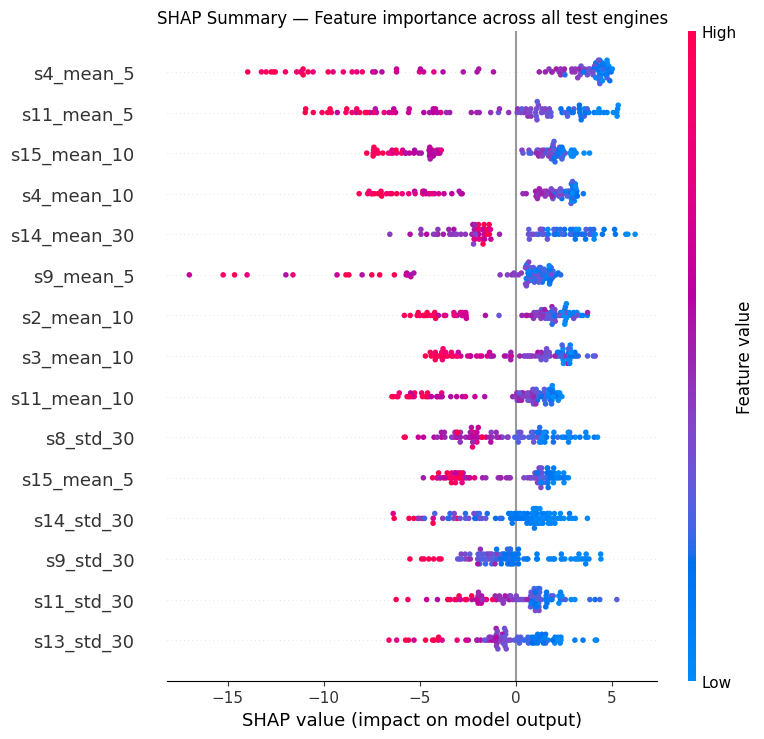

Summary plot saved.


In [4]:
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test_last,
    feature_names=feature_cols,
    max_display=15,
    show=False
)
plt.title("SHAP Summary — Feature importance across all test engines")
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Summary plot saved.")

Highest risk engine: 34.0
Predicted RUL: 6.2 cycles


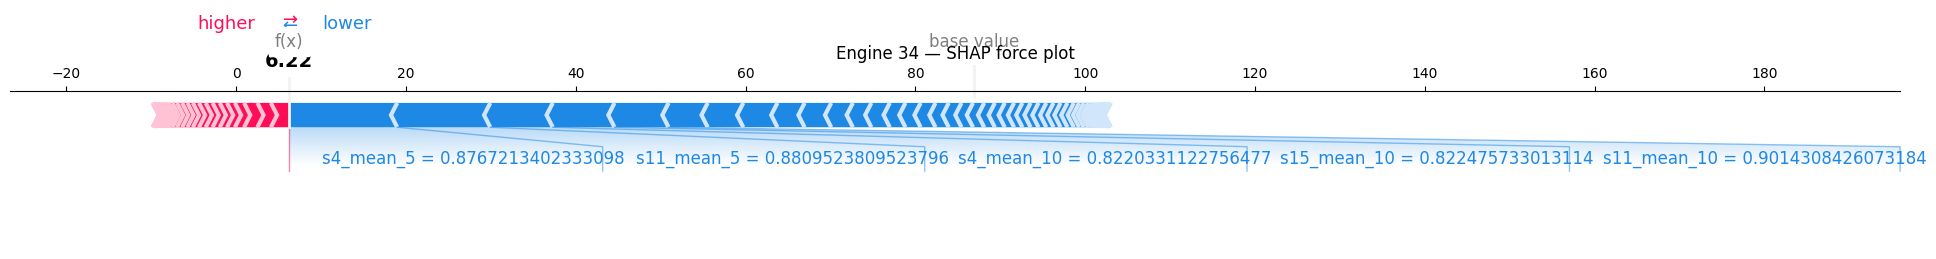

In [5]:
# Pick the highest risk engine - the one with lowest predicted RUL
predictions = model.predict(X_test_last)
highest_risk_idx = np.argmin(predictions)
highest_risk_engine = test_last.iloc[highest_risk_idx]['engine_id']

print(f"Highest risk engine: {highest_risk_engine}")
print(f"Predicted RUL: {predictions[highest_risk_idx]:.1f} cycles")

# Force plot for this engine
shap.force_plot(
    explainer.expected_value,
    shap_values[highest_risk_idx],
    X_test_last.iloc[highest_risk_idx],
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.title(f"Engine {int(highest_risk_engine)} — SHAP force plot")
plt.tight_layout()
plt.savefig('../models/shap_force_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
def get_top_contributions(engine_idx, shap_vals, feature_names, top_n=5):
    """
    For one engine, return the top N sensors driving the prediction,
    with their SHAP values and direction.
    """
    engine_shap = shap_vals[engine_idx]
    
    # Create a series of feature -> shap value
    shap_series = pd.Series(engine_shap, index=feature_names)
    
    # Sort by absolute value - biggest impact first
    top_features = shap_series.abs().sort_values(ascending=False).head(top_n)
    
    contributions = []
    for feature in top_features.index:
        shap_val = shap_series[feature]
        contributions.append({
            'feature': feature,
            'shap_value': round(float(shap_val), 4),
            'direction': 'increasing risk' if shap_val < 0 else 'decreasing risk',
            'impact': 'HIGH' if abs(shap_val) > 5 else 'MEDIUM' if abs(shap_val) > 2 else 'LOW'
        })
    
    return contributions

# Test it on the highest risk engine
contributions = get_top_contributions(
    highest_risk_idx, 
    shap_values, 
    feature_cols
)

print(f"Top contributing factors for Engine {int(highest_risk_engine)}:")
print()
for c in contributions:
    arrow = "↑ RISK" if c['direction'] == 'increasing risk' else "↓ risk"
    print(f"  {c['feature']:<20} {arrow}  SHAP: {c['shap_value']:>8.4f}  Impact: {c['impact']}")

Top contributing factors for Engine 34:

  s4_mean_5            ↑ RISK  SHAP: -12.7438  Impact: HIGH
  s11_mean_5           ↑ RISK  SHAP: -10.9642  Impact: HIGH
  s4_mean_10           ↑ RISK  SHAP:  -7.3595  Impact: HIGH
  s15_mean_10          ↑ RISK  SHAP:  -7.2737  Impact: HIGH
  s11_mean_10          ↑ RISK  SHAP:  -6.3607  Impact: HIGH


In [7]:
def format_shap_for_prompt(contributions):
    """
    Converts SHAP contributions list into a readable string
    for the LLM work order prompt.
    """
    lines = []
    for c in contributions:
        # Make the feature name human readable
        feature = c['feature']
        # e.g. s4_mean_30 -> "s4 (30-cycle rolling mean)"
        parts = feature.split('_')
        if len(parts) == 3:
            sensor, _, window = parts
            readable = f"{sensor} ({window}-cycle rolling mean)"
        elif len(parts) == 3 and parts[1] == 'std':
            sensor, _, window = parts
            readable = f"{sensor} ({window}-cycle rolling std dev)"
        else:
            readable = feature
            
        direction = "↑ PUSHING TOWARD FAILURE" if c['direction'] == 'increasing risk' else "↓ stable/healthy"
        lines.append(f"  - {readable}: {direction} (SHAP: {c['shap_value']:.3f}, Impact: {c['impact']})")
    
    return "\n".join(lines)

# Test it
formatted = format_shap_for_prompt(contributions)
print("Formatted for LLM prompt:")
print(formatted)

Formatted for LLM prompt:
  - s4 (5-cycle rolling mean): ↑ PUSHING TOWARD FAILURE (SHAP: -12.744, Impact: HIGH)
  - s11 (5-cycle rolling mean): ↑ PUSHING TOWARD FAILURE (SHAP: -10.964, Impact: HIGH)
  - s4 (10-cycle rolling mean): ↑ PUSHING TOWARD FAILURE (SHAP: -7.359, Impact: HIGH)
  - s15 (10-cycle rolling mean): ↑ PUSHING TOWARD FAILURE (SHAP: -7.274, Impact: HIGH)
  - s11 (10-cycle rolling mean): ↑ PUSHING TOWARD FAILURE (SHAP: -6.361, Impact: HIGH)


In [8]:
# Save explainer for use in the app
joblib.dump(explainer, '../models/shap_explainer.pkl')
joblib.dump(shap_values, '../models/shap_values_test.pkl')

print("Saved:")
print("  models/shap_explainer.pkl")
print("  models/shap_values_test.pkl")

Saved:
  models/shap_explainer.pkl
  models/shap_values_test.pkl


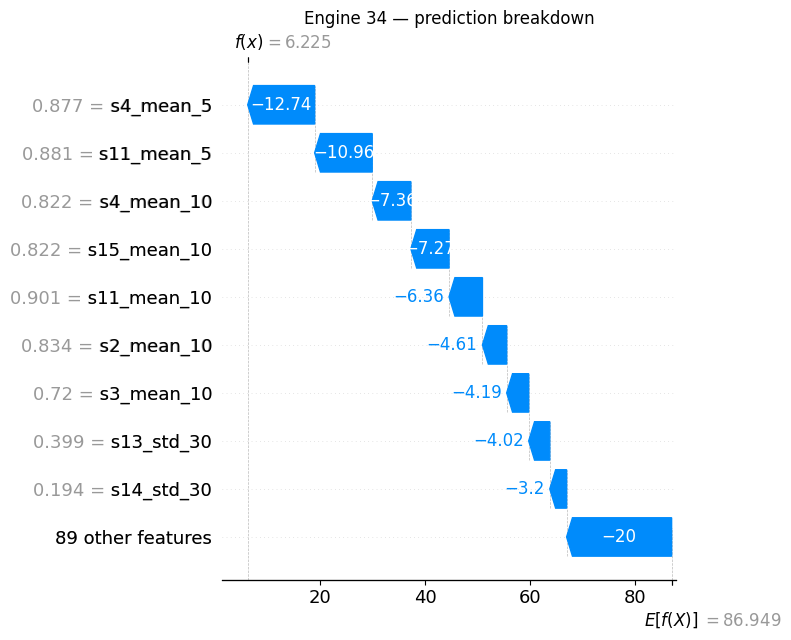

In [9]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test_last.iloc[highest_risk_idx].values,
        feature_names=feature_cols
    ),
    max_display=10,
    show=False
)
plt.title(f"Engine {int(highest_risk_engine)} — prediction breakdown")
plt.tight_layout()
plt.savefig('../models/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()